In [1]:
from tqdm import tqdm
from pprint import pprint
import numpy as np

In [2]:
# -------------------------
# Constants
# -------------------------

dataset_detail=np.load("/mnt/Extra/Project_Storage/stereo_ML_dataset/org/"+"detail.npy", allow_pickle=True)
dataset_detail=dataset_detail.tolist()

patch_shape = (int(dataset_detail[0]),int(dataset_detail[1]))

target = min(int(dataset_detail[2]*0.8),int(2**17+1))
# target=1000

Dmax = int(dataset_detail[3])
Dmin = int(dataset_detail[4])

resize_fraction = dataset_detail[5]
resize_factor = 1/resize_fraction

feature_dimension =int (dataset_detail[6])

disparity_skip = int(dataset_detail[7])

eff_Dmax = (Dmax-Dmin)//(disparity_skip+1)


In [3]:

org_path = "/mnt/Extra/Project_Storage/stereo_ML_dataset/"
dataset_org_path = "/mnt/Extra/Project_Storage/stereo_ML_dataset/train/sampled/"

# -------------------------
# Load memmap datasets
# -------------------------
left_patch_memmap = dataset_org_path + "left_patch.dat"
# left_feat_memmap = dataset_org_path + "left_feat.dat"
right_strip_memmap = dataset_org_path + "right_strip.dat"
# right_feat_memmap = dataset_org_path + "right_feat.dat"
patch_disparity_memmap = dataset_org_path + "patch_disp.dat"


model_location = org_path+"model/"

left_patches  = np.memmap(left_patch_memmap, dtype=np.float16, mode='r', shape=(target, patch_shape[0], patch_shape[1]))
# patch_feat =np.memmap(left_feat_memmap, dtype=np.float16, mode='r', shape=(target, feature_dimension))

right_strips  = np.memmap(right_strip_memmap, dtype=np.float16, mode='r', shape=(target, eff_Dmax, patch_shape[0], patch_shape[1] ))
# strip_feat =np.memmap(right_feat_memmap, dtype=np.float16, mode='r', shape=(target,  eff_Dmax, feature_dimension))

median_disp   = np.memmap(patch_disparity_memmap, dtype=np.int16, mode='r', shape=(target,))

# default_mask = np.ones((target, eff_Dmax), dtype=np.bool_)



In [ ]:

import numpy as np
import cv2
from skimage.feature import local_binary_pattern
from scipy.fftpack import dct

def compute_patch_features(patch, eps=1e-6):
    """
    Compute extended 16-dimensional features for a single patch, combining:
      - Statistical, frequency, and texture descriptors (11 from the original)
      - Basic gradient/Laplacian means (5 from compute_features)
    
    Input:
        patch : np.ndarray of shape (H, W), dtype=float16 or float32, normalized to [0,1]
    Output:
        features : np.ndarray of shape (16,), all roughly in [0,1]
    """
    patch = patch.astype(np.float32)
    H, W = patch.shape
    patch_normal = (patch * 255).astype(np.uint8)

    # --------------------
    # 1. Basic statistics
    # --------------------
    mean_val = patch.mean()
    std_val = np.std(patch) / 0.5
    skew_val = np.mean(((patch - mean_val) / (np.std(patch) + eps))**3)
    skew_val = (skew_val + 2) / 4
    kurt_val = np.mean(((patch - mean_val) / (np.std(patch) + eps))**4)
    kurt_val = (kurt_val - 1) / 8

    # --------------------
    # 2. Laplacian energy
    # --------------------
    lap = cv2.Laplacian(patch, cv2.CV_32F)
    lap_energy = np.mean(lap**2) / 500.0

    # --------------------
    # 3. Gradients
    # --------------------
    gx = cv2.Sobel(patch, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(patch, cv2.CV_32F, 0, 1, ksize=3)
    mag = np.sqrt(gx**2 + gy**2)
    ori = np.arctan2(gy, gx)

    # Histograms
    mag_hist, _ = np.histogram(mag, bins=8, range=(0, np.max(mag) + eps))
    mag_hist = mag_hist / (mag_hist.sum() + eps)
    mag_mean = np.average(np.arange(1, 9), weights=mag_hist)

    ori_hist, _ = np.histogram(ori, bins=8, range=(-np.pi, np.pi))
    ori_hist = ori_hist / (ori_hist.sum() + eps)
    ori_mean = np.average(np.arange(1, 9), weights=ori_hist)

    # --------------------
    # 4. LBP histogram
    # --------------------
    lbp = local_binary_pattern(patch_normal, P=8, R=1, method='uniform')
    lbp_hist, _ = np.histogram(lbp, bins=10, range=(0, 10))
    lbp_hist = lbp_hist / (lbp_hist.sum() + eps)
    lbp_mean = np.average(np.arange(1, 11), weights=lbp_hist)

    # --------------------
    # 5. DCT coefficients
    # --------------------
    patch_dct = dct(dct(patch.T, norm='ortho').T, norm='ortho')
    dct_coeffs = patch_dct[:5, :5].flatten()
    dct_mean = np.mean(np.abs(dct_coeffs))

    # --------------------
    # 6. Edge density
    # --------------------
    edges = cv2.Canny(patch_normal, 50, 150)
    edge_density = edges.mean() / 255.0

    # --------------------
    # 7. Entropy
    # --------------------
    hist, _ = np.histogram(patch_normal, bins=256, range=(0, 255))
    p = hist / (hist.sum() + eps)
    entropy = -np.sum(p * np.log2(p + eps)) / 8.0

    # --------------------
    # 8. Extra features (from compute_features)
    # --------------------
    sobel_x_mean = gx.mean()
    sobel_y_mean = gy.mean()
    sobel_x_n = (sobel_x_mean + 1) / 2
    sobel_y_n = (sobel_y_mean + 1) / 2
    lap_mean = lap.mean()
    lap_mean_n = (lap_mean + 1) / 2

    # --------------------
    # Combine all 16 features
    # --------------------
    features = np.array([
        mean_val, std_val, skew_val, kurt_val, lap_energy,   # 1–5
        mag_mean, ori_mean, lbp_mean, dct_mean, edge_density, entropy,  # 6–11
        sobel_x_n, sobel_y_n, lap_mean_n # 12–14 new
    ], dtype=np.float32)

    # Normalize to [0,1] and clip for safety
    features = np.clip(features, 0.0, 1.0)
    return features

In [5]:
import numpy as np

def compute_delta_feature_arrays(left_patch, right_patches, true_disp, Dmax):
    """
    left_patch: (H,W) normalized float16 patch
    right_patches: (Dmax, H, W) normalized float16 patches
    true_disp: integer, index of the true patch in right_patches
    Dmax: number of candidate patches
    compute_patch_features: function that returns feature array for a patch
    """
    
    # Convert to float32
    left_patch = left_patch.astype(np.float32)
    right_patches = right_patches.astype(np.float32)
    
    # Compute features
    left_feat = compute_patch_features(left_patch)          # shape (F,)
    right_feats = np.array([compute_patch_features(p) for p in right_patches])  # shape (Dmax, F)
    
    # Feature difference
    feat_diff = right_feats - left_feat[None, :]            # shape (Dmax, F)
    
    F = left_feat.shape[0]
    
    # Initialize array to hold delta arrays for each feature
    delta_arrays = np.zeros((F, 2*Dmax-1), dtype=np.float32)
    
    # Fill delta arrays
    for f in range(F):
        for idx in range(Dmax):
            delta_idx = idx - true_disp + Dmax - 1  # index in 0..2*Dmax-2
            delta_arrays[f, delta_idx] = np.abs(feat_diff[idx, f])
            
    
    
    # return left_feat, right_feats, feat_diff, delta_arrays
    return delta_arrays


In [6]:
import numpy as np
from tqdm import tqdm
from multiprocessing import Pool, cpu_count

def _compute_single_sample(args):
    """Helper to compute delta arrays for one sample."""
    i, left_patch, right_patches, true_disp, Dmax = args
    return compute_delta_feature_arrays(left_patch, right_patches, true_disp, Dmax)

def compute_delta_features(F_size, left_patches, right_strips, true_disps, Dmax, num_workers=None):
    """
    Parallelized version that collects all delta arrays first,
    then averages them at the end.
    """
    N = left_patches.shape[0]
    F = F_size

    # Prepare argument list
    args_list = [
        (i, left_patches[i].astype(np.float32),
         right_strips[i].astype(np.float32),
         true_disps[i], Dmax)
        for i in range(N)
    ]

    # Decide number of workers
    if num_workers is None:
        num_workers = max(1, cpu_count() - 1)

    # Collect all results in a list
    with Pool(processes=num_workers) as pool:
        all_results = list(tqdm(pool.imap_unordered(_compute_single_sample, args_list), total=N))

    # Stack and compute mean across samples
    all_results = np.stack(all_results, axis=0)  # (N, F, 2*Dmax-1)
    mean_delta_arrays = np.mean(all_results, axis=0)  # (F, 2*Dmax-1)

    return mean_delta_arrays


In [ ]:
F_size = compute_patch_features(np.zeros(left_patches.shape[1:], dtype=np.float32)).shape[0]

mean_feature_errors = compute_delta_features(F_size, left_patches, right_strips, median_disp, eff_Dmax)

 27%|██▋       | 34972/131073 [01:18<03:22, 474.01it/s]

In [ ]:

import matplotlib.pyplot as plt
import numpy as np
import math

def plot_delta_features(delta_array):
    """
    delta_array: np.array of shape (F, 2*Dmax-1)
                 Each row corresponds to a feature.
    
    Plots F graphs in a grid, 5 graphs per row, x-axis from -(Dmax-1) to +(Dmax-1)
    """
    F, length = delta_array.shape
    assert length % 2 == 1, "Second dimension should be odd"
    
    Dmax = (length + 1) // 2
    x = np.arange(-(Dmax-1), Dmax, 1)  # x-axis: -(Dmax-1) to +(Dmax-1)
    
    cols = 5
    rows = math.ceil(F / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows))
    axes = axes.flatten()  # Flatten in case we have multiple rows
    
    for i in range(F):
        axes[i].plot(x, delta_array[i])
        axes[i].set_title(f'Feature {i+1}')
        axes[i].set_xlabel('Delta index')
        axes[i].set_ylabel('Value')
        axes[i].grid(True)
    
    # Hide unused subplots if F is not multiple of cols
    for j in range(F, rows*cols):
        axes[j].axis('off')
    
    plt.tight_layout()
    plt.show()
    
import matplotlib.pyplot as plt
import numpy as np

def plot_single_feature(delta_array, feature_name="Feature"):
    """
    delta_array: 1D np.array of length 2*Dmax-1
                 Represents a single feature's values across delta positions.
    
    Plots a single graph with x-axis from -(Dmax-1) to +(Dmax-1)
    """
    length = delta_array.shape[0]
    assert length % 2 == 1, "Length of array should be odd"
    
    Dmax = (length + 1) // 2
    x = np.arange(-(Dmax-1), Dmax, 1)  # x-axis: -(Dmax-1) to +(Dmax-1)
    
    plt.figure(figsize=(8,4))
    plt.plot(x, delta_array, marker='o')
    plt.title(f'{feature_name}')
    plt.xlabel('Delta index')
    plt.ylabel('Value')
    plt.grid(True)
    plt.show()



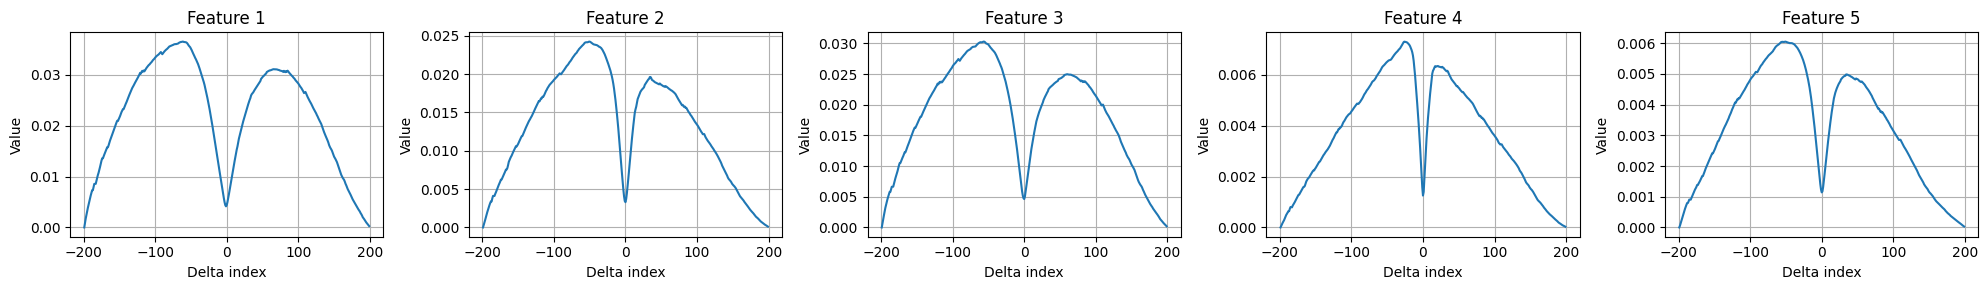

In [ ]:
plot_delta_features(mean_feature_errors)

In [ ]:
import numpy as np

def compute_feature_weights(max_vals, base_vals, eps=1e-6):
    """
    Compute normalized feature weights based on max and base error values.
    
    Args:
        max_vals (array-like): maximum error values per feature
        base_vals (array-like): base (0-disparity) error values per feature
        eps (float): small value for stability
    
    Returns:
        np.ndarray: normalized weights summing to 1
    """
    max_vals = np.array(max_vals, dtype=np.float32)
    base_vals = np.array(base_vals, dtype=np.float32)
    
    contrast = max_vals - base_vals
    score = contrast / (base_vals + eps)
    weights = score / np.sum(score)
    return weights

valid_indices = [i for i in range(F_size)]


maxima = np.max(mean_feature_errors, axis=1)[valid_indices]
base = mean_feature_errors[:, eff_Dmax][valid_indices]

weights = compute_feature_weights(maxima, base)

print(maxima)
print(base)
print("\n")
print((base/maxima)*100)
print("\n")
print(np.round(weights, 3))


[0.03653324 0.02423006 0.03028121 0.00730028 0.00605489]
[0.00497474 0.00371532 0.00506834 0.00139798 0.00117668]


[13.617023 15.33352  16.73758  19.149717 19.433624]


[0.252 0.219 0.197 0.167 0.164]


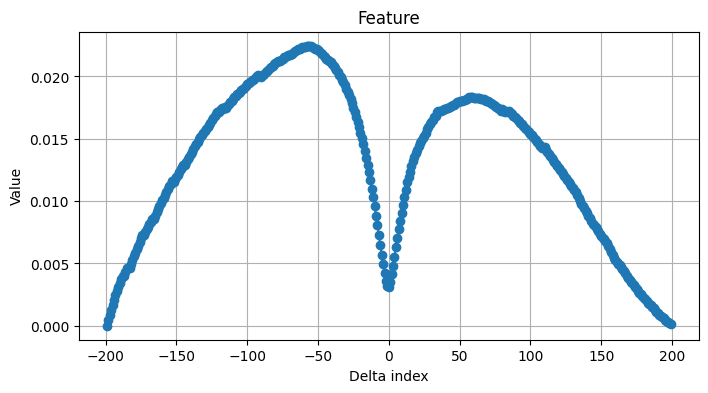



0.022460714
0.0034940622


15.556328


In [ ]:

valid_combined_error = np.sum(mean_feature_errors[valid_indices] * weights[:, np.newaxis], axis=0)

plot_single_feature(valid_combined_error)

valid_maxima = np.max(valid_combined_error)
valid_base = valid_combined_error[eff_Dmax]

print("\n")
print(valid_maxima)
print(valid_base)
print("\n")
print((valid_base/valid_maxima)*100)